In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col=0, parse_dates=True)
irx = pd.read_csv("../data/irx.csv", index_col=0, parse_dates=True)

print(f"Prices: {prices.index.min().date()} to {prices.index.max().date()}, {prices.shape[0]} rows, {prices.shape[1]} assets")
print(f"IRX: {irx.index.min().date()} to {irx.index.max().date()}, {len(irx)} rows")

print("\nMissing values per ETF:")
print(prices.isna().sum().to_string())
print(f"\nIRX missing values: {irx.isna().sum().sum()}")

Prices: 2007-01-03 to 2026-09-30, 4967 rows, 10 assets
IRX: 2007-01-03 to 2026-09-30, 4965 rows

Missing values per ETF:
SPY     0
EFA     0
EEM     0
TLT     0
IEF     0
LQD     0
HYG    67
GLD     0
VNQ     0
DBC     0

IRX missing values: 0


In [2]:
monthly_prices = prices.resample("ME").last()
monthly_returns = monthly_prices.pct_change().dropna()

print(f"Monthly returns: {monthly_returns.index.min().date()} to {monthly_returns.index.max().date()}, {len(monthly_returns)} months")
print(f"Missing values remaining: {monthly_returns.isna().sum().sum()}")
monthly_returns.head()

Monthly returns: 2007-05-31 to 2026-09-30, 233 months
Missing values remaining: 0


,SPY,EFA,EEM,TLT,IEF,LQD,HYG,GLD,VNQ,DBC
Date,,,,,,,,,,
2007-05-31,0.033920,0.023623,0.050646,-0.023138,-0.013935,-0.012307,0.003732,-0.023103,-0.003786,-0.002346
2007-06-30,-0.014621,-0.003209,0.036783,-0.010135,-0.004677,-0.008100,-0.031525,-0.019378,-0.090077,0.007448
2007-07-31,-0.031310,-0.022904,0.007141,0.033190,0.022568,-0.008242,-0.038802,0.023650,-0.082593,0.019066
2007-08-31,0.012833,-0.006336,0.010409,0.017877,0.022631,0.023863,0.051940,0.011096,0.067445,-0.019091
2007-09-30,0.038714,0.053176,0.115715,0.002282,0.000883,0.007333,0.029224,0.105081,0.039172,0.094200


Risk-free rate: 2007-05-31 to 2026-09-30, missing: 0
Average annualized risk-free rate: 1.48%


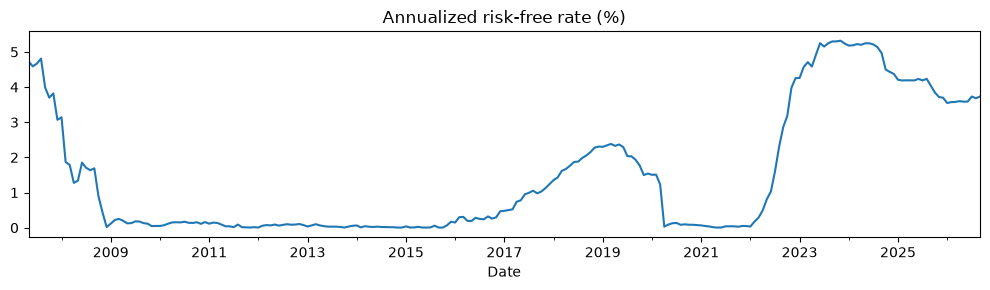

In [3]:
irx_monthly = irx.iloc[:, 0].resample("ME").last()

# Convert annual percentage yield to a monthly decimal rate,
# shifted so each month uses the rate known at the START of that month
rf_monthly = (irx_monthly / 100 / 12).shift(1)
rf_monthly = rf_monthly.reindex(monthly_returns.index)
rf_monthly.name = "rf"

print(f"Risk-free rate: {rf_monthly.index.min().date()} to {rf_monthly.index.max().date()}, missing: {rf_monthly.isna().sum()}")
print(f"Average annualized risk-free rate: {rf_monthly.mean() * 12:.2%}")

(rf_monthly * 12 * 100).plot(figsize=(10, 3), title="Annualized risk-free rate (%)")
plt.tight_layout()
plt.show()

In [4]:
excess = monthly_returns.sub(rf_monthly, axis=0)
n_years = len(monthly_returns) / 12

summary = pd.DataFrame({
    "ann_return": monthly_returns.mean() * 12,
    "ann_vol": monthly_returns.std() * np.sqrt(12),
    "sharpe": (excess.mean() * 12) / (excess.std() * np.sqrt(12)),
})

# Standard error of the annualized mean return estimate
summary["se_of_mean"] = summary["ann_vol"] / np.sqrt(n_years)

summary.sort_values("sharpe", ascending=False).round(3)

,ann_return,ann_vol,sharpe,se_of_mean
SPY,0.115,0.155,0.648,0.035
GLD,0.105,0.176,0.515,0.040
HYG,0.051,0.102,0.356,0.023
LQD,0.040,0.082,0.305,0.019
VNQ,0.074,0.222,0.265,0.050
EEM,0.069,0.210,0.258,0.048
EFA,0.059,0.173,0.256,0.039
IEF,0.031,0.067,0.244,0.015
DBC,0.041,0.191,0.139,0.043
TLT,0.034,0.141,0.137,0.032


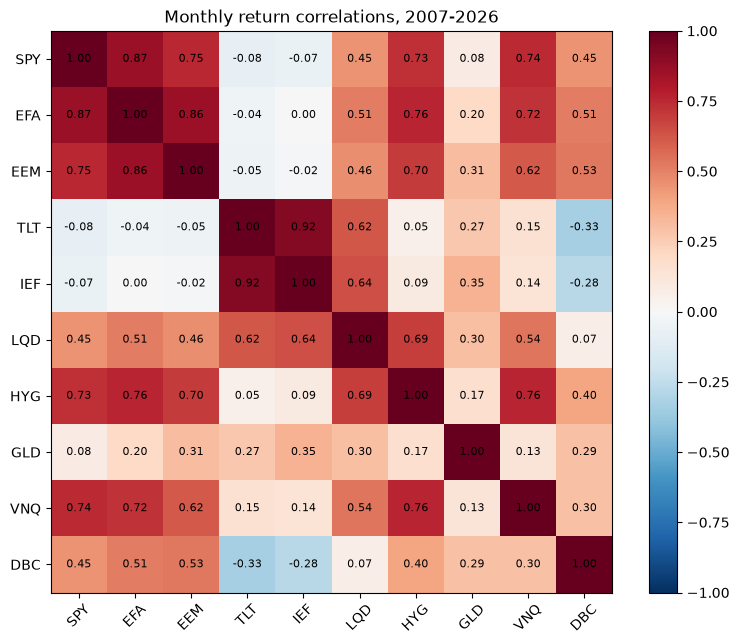

In [5]:
corr = monthly_returns.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im)
ax.set_title("Monthly return correlations, 2007-2026")
plt.tight_layout()
plt.show()

In [6]:
monthly_returns.to_csv("../data/monthly_returns.csv")
rf_monthly.to_csv("../data/rf_monthly.csv")
print("Saved monthly_returns.csv and rf_monthly.csv")

Saved monthly_returns.csv and rf_monthly.csv
